In [1]:
import tensorflow as tf
print(tf.keras.__version__)


3.13.2


In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [14]:
import zipfile

with zipfile.ZipFile("devnagari digit.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Dataset folder extracted successfully!")

Dataset folder extracted successfully!


In [16]:
import os 
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

In [19]:
# Dataset paths
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir = "DevanagariHandwrittenDigitDataset/Test/"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}
    
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            
            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0
            
            images.append(img)
            labels.append(label)
    
    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Flatten for FCN
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

Train shape: (17000, 28, 28, 1) (17000, 10)
Test shape: (3000, 28, 28, 1) (3000, 10)


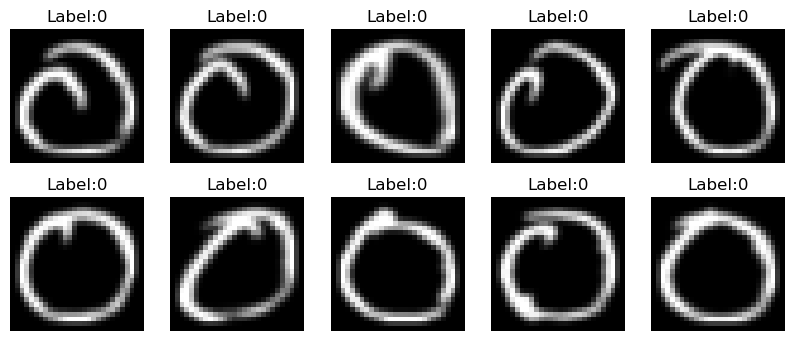

In [23]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28),cmap="gray")
    plt.title(f"Label:{np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

In [37]:
# building a fcn model
model =keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),#Flattenthe28x28imagetoa784-dimensionalvector
        keras.layers.Dense(64,activation="sigmoid"),
        keras.layers.Dense(128,activation="sigmoid"),
        keras.layers.Dense(256,activation="sigmoid"),
        keras.layers.Dense(num_classes,activation="softmax"),
    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled")

Model compiled


Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9069 - loss: 0.2866 - val_accuracy: 0.0000e+00 - val_loss: 9.7283
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9422 - loss: 0.1903 - val_accuracy: 0.0000e+00 - val_loss: 10.1380
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9582 - loss: 0.1416 - val_accuracy: 0.0000e+00 - val_loss: 10.4469
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9671 - loss: 0.1109 - val_accuracy: 0.0000e+00 - val_loss: 10.9130
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9717 - loss: 0.0926 - val_accuracy: 0.0000e+00 - val_loss: 10.9433
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9779 - loss: 0.0763 - val_accuracy: 0.0000e+00 - val_loss: 11.0525


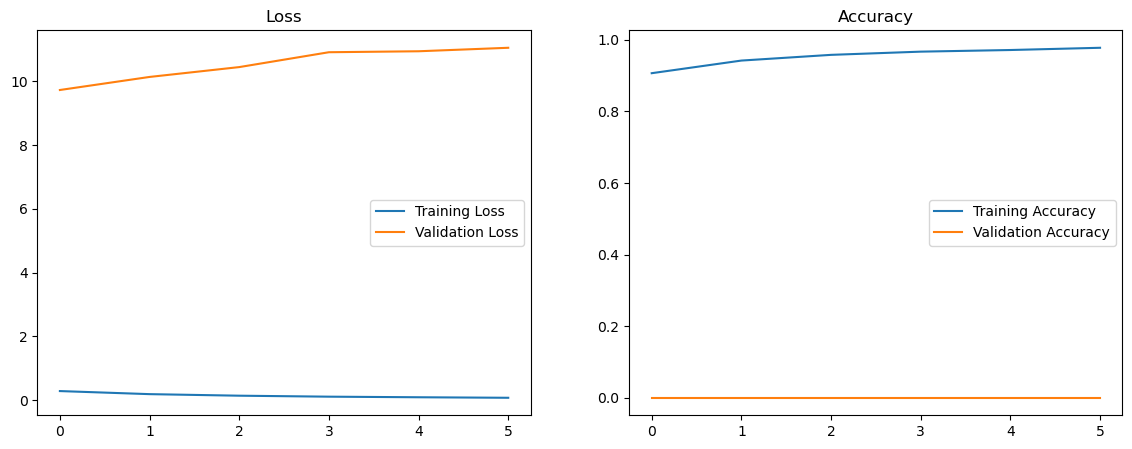

In [51]:
batch_size = 128
epochs = 100

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("devnagari_model.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

In [53]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

94/94 - 0s - 2ms/step - accuracy: 0.7420 - loss: 2.1343

Test Loss: 2.1343
Test Accuracy: 74.20%


In [55]:

model.save("devnagari_fcn_model.h5")

loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded Model Test Accuracy: {loaded_acc*100:.2f}%")

Loaded Model Test Accuracy: 74.20%



First 10 predictions vs true labels:
Image  1 → Predicted: 0 | True: 0
Image  2 → Predicted: 0 | True: 0
Image  3 → Predicted: 0 | True: 0
Image  4 → Predicted: 0 | True: 0
Image  5 → Predicted: 0 | True: 0
Image  6 → Predicted: 0 | True: 0
Image  7 → Predicted: 0 | True: 0
Image  8 → Predicted: 0 | True: 0
Image  9 → Predicted: 0 | True: 0
Image 10 → Predicted: 0 | True: 0


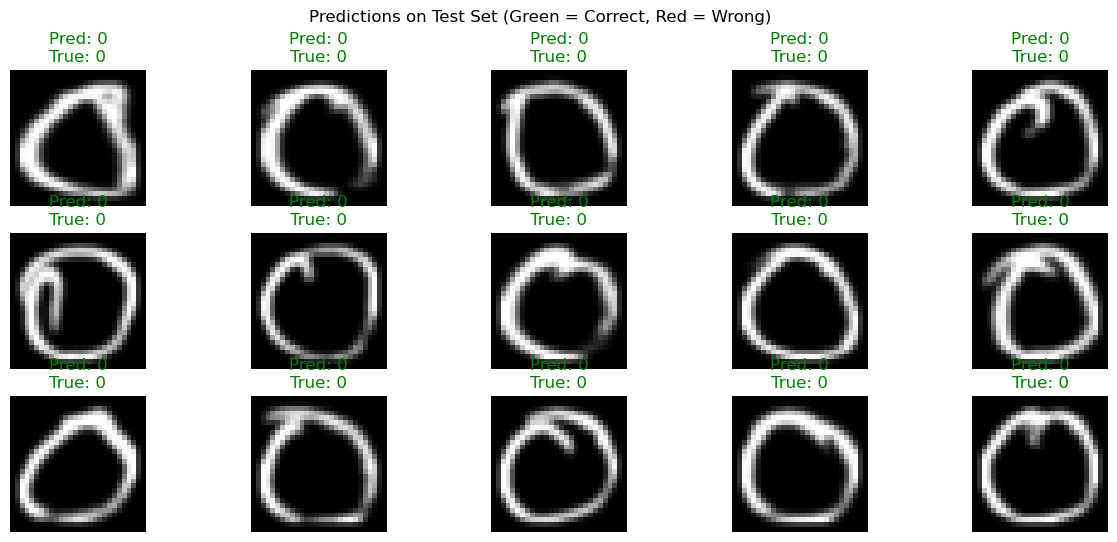

In [57]:
predictions = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("\nFirst 10 predictions vs true labels:")
for i in range(10):
    print(f"Image {i+1:2d} → Predicted: {predicted_labels[i]} | True: {true_labels[i]}")

plt.figure(figsize=(15, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}", color=color)
    plt.axis("off")
plt.suptitle("Predictions on Test Set (Green = Correct, Red = Wrong)")
plt.show()